# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Цель лабораторной работы: изучение способов предварительной обработки данных для дальнейшего формирования моделей.

**Задание:**

Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.)
Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

    обработку пропусков в данных;
    кодирование категориальных признаков;
    масштабирование данных.



## Часть 1. Импорт необходимых библиотек и загрузка данных

Для работы нам потребуются библиотеки `pandas` для обработки табличных данных, `numpy` для числовых операций, `matplotlib` и `seaborn` для визуализации, а также модули из `scikit-learn` для предобработки данных.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов машинного обучения из scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler


%matplotlib inline 
sns.set(style="ticks")

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


### 1.1. Загрузка и первичный осмотр датасета

Загрузим CSV-файл в DataFrame `df` и посмотрим на его структуру: общее количество строк и столбцов, а также первые 5 записей для понимания формата данных.

In [4]:
file_path = 'Video_Games_Sales_as_at_22_Dec_2016.csv' 
df = pd.read_csv(file_path)

print("Размер датасета (строки, колонки):", df.shape)
print("\nПервые 5 строк датасета:")
df.head()

Размер датасета (строки, колонки): (16719, 16)

Первые 5 строк датасета:


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2. Анализ типов данных и наличия пропусков

Выведем общую информацию о датасете с помощью метода `.info()`. Это позволит увидеть названия всех колонок, количество непустых (non-null) значений в каждой из них и их типы данных. Также посмотрим на основные статистические характеристики числовых признаков с помощью `.describe()`.

In [5]:
print("Информация о типах данных и пропусках")
df.info()

print("\n\nСтатистика по числовым данным")
df.describe()

Информация о типах данных и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), objec

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


## 2. Обработка пропусков в данных

Рассмотрим стратегии импьютации - заполнения пропущенных значений для числовых и категориальных признаков.


### 2.1. Обработка пропусков в числовом признаке `Year_of_Release`

Признак **Year_of_Release** (год выпуска) имеет числовой тип `float64`. 

1. Оценим количество и процент пропусков.
2. Построим гистограмму распределения значений, чтобы понять, какую меру центральной тенденции лучше использовать для заполнения (среднее или медиану). Если распределение скошено или есть выбросы, медиана предпочтительнее.

Количество пропусков в Year_of_Release: 269
Процент пропусков: 1.61%


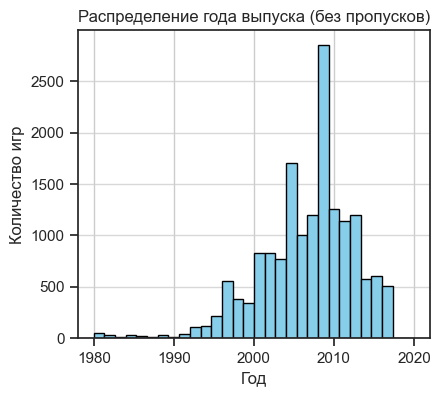

In [6]:
print("Количество пропусков в Year_of_Release:", df['Year_of_Release'].isnull().sum())
print("Процент пропусков: {:.2f}%".format(df['Year_of_Release'].isnull().sum() / len(df) * 100))

# Посмотрим на распределение (гистограмму) для обоснования выбора стратегии
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Year_of_Release'].dropna().hist(bins=30, edgecolor='black', color='skyblue')
plt.title('Распределение года выпуска (без пропусков)')
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 2.2. Заполнение пропусков в `Year_of_Release` медианой

Используем класс `SimpleImputer` из библиотеки `scikit-learn` со стратегией `median`. 

In [7]:
df_imputed = df.copy()

imputer_median = SimpleImputer(strategy='median')

# Обучаем и трансформируем колонку
df_imputed['Year_of_Release'] = imputer_median.fit_transform(df_imputed[['Year_of_Release']])

# Проверяем результат
print("Пропусков после обработки:", df_imputed['Year_of_Release'].isnull().sum())
print("\nСтатистика после заполнения медианой:")
print(df_imputed['Year_of_Release'].describe())
print("\nМедианное значение, которым были заполнены пропуски:", imputer_median.statistics_[0])

Пропусков после обработки: 0

Статистика после заполнения медианой:
count    16719.000000
mean      2006.495604
std          5.831862
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year_of_Release, dtype: float64

Медианное значение, которым были заполнены пропуски: 2007.0


### 2.3. Обработка пропусков в категориальном признаке `Rating`

Признак **Rating** (возрастной рейтинг) имеет категориальный тип `object`. Посмотрим на уникальные значения в этой колонке. Мы увидим, что часть значений представлена строковыми категориями (`'E'`, `'T'`, `'M'` и т.д.), а часть отсутствует (`NaN`).

In [8]:
print("Уникальные значения в Rating до обработки:")
print(df_imputed['Rating'].unique())
print("\nКоличество пропусков (NaN):", df_imputed['Rating'].isnull().sum())

Уникальные значения в Rating до обработки:
['E' nan 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']

Количество пропусков (NaN): 6769


### 2.4. Заполнение пропусков в `Rating` константой 'Unknown'

Для категориальных признаков создатим новую категорию `'Unknown'` (Неизвестно). 
Используем `SimpleImputer` со стратегией `constant` и параметром `fill_value='Unknown'`.

In [9]:
imputer_constant = SimpleImputer(strategy='constant', fill_value='Unknown')

df_imputed['Rating'] = imputer_constant.fit_transform(df_imputed[['Rating']]).ravel()

print("Уникальные значения в Rating после обработки:")
print(df_imputed['Rating'].unique())
print("\nКоличество пропусков:", df_imputed['Rating'].isnull().sum())

Уникальные значения в Rating после обработки:
['E' 'Unknown' 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']

Количество пропусков: 0


## 3. Кодирование категориальных признаков

Текстовые категории необходимо преобразовать в числовой формат.

1.  **Label Encoding** — каждое уникальное значение кодируется целым числом (на примере жанра `Genre`).
2.  **One-Hot Encoding** — каждое уникальное значение становится отдельной бинарной колонкой (на примере платформы `Platform`).
3.  **Ручное кодирование порядковых шкал** — задание порядка категорий вручную с помощью словаря (на примере рейтинга `Rating`).

### 3.1. Label Encoding для признака `Genre`

Применим `LabelEncoder` к колонке `Genre`. Каждому жанру будет присвоен уникальный номер от 0 до N-1. 


In [10]:
df_encoded = df_imputed.copy()
le = LabelEncoder()

df_encoded['Genre_LabelEncoded'] = le.fit_transform(df_encoded['Genre'])

print("Пример Label Encoding для жанра (первые 10 строк):")
print(df_encoded[['Genre', 'Genre_LabelEncoded']].head(10))
print("\nСоответствие кодов (первые 5):")
for i, genre in enumerate(le.classes_[:5]):
    print(f"Код {i} -> {genre}")

Пример Label Encoding для жанра (первые 10 строк):
          Genre  Genre_LabelEncoded
0        Sports                  10
1      Platform                   4
2        Racing                   6
3        Sports                  10
4  Role-Playing                   7
5        Puzzle                   5
6      Platform                   4
7          Misc                   3
8      Platform                   4
9       Shooter                   8

Соответствие кодов (первые 5):
Код 0 -> Action
Код 1 -> Adventure
Код 2 -> Fighting
Код 3 -> Misc
Код 4 -> Platform


### 3.2. One-Hot Encoding для признака `Platform`

Используем функцию `pd.get_dummies()` для быстрого One-Hot кодирования платформ. Для каждой уникальной платформы (PS4, X360, PC, PS3 и т.д.) будет создана отдельная колонка со значениями 0 или 1. 

In [11]:
# Создаем датафрейм с One-Hot Encoding для платформ
platform_dummies = pd.get_dummies(df_encoded['Platform'], prefix='Platform')

# Присоединяем к основному датафрейму
df_encoded = pd.concat([df_encoded, platform_dummies], axis=1)

print("Таблица после добавления One-Hot Encoding для платформ (первые 5 колонок):")
cols_to_show = ['Name', 'Platform'] + list(platform_dummies.columns[:5])
print(df_encoded[cols_to_show].head())
print("\nВсего создано колонок для платформ:", len(platform_dummies.columns))

Таблица после добавления One-Hot Encoding для платформ (первые 5 колонок):
                       Name Platform  Platform_2600  Platform_3DO  \
0                Wii Sports      Wii          False         False   
1         Super Mario Bros.      NES          False         False   
2            Mario Kart Wii      Wii          False         False   
3         Wii Sports Resort      Wii          False         False   
4  Pokemon Red/Pokemon Blue       GB          False         False   

   Platform_3DS  Platform_DC  Platform_DS  
0         False        False        False  
1         False        False        False  
2         False        False        False  
3         False        False        False  
4         False        False        False  

Всего создано колонок для платформ: 31


### 3.3. Кодирование порядковой шкалы для признака `Rating`

Рейтинг имеет строгий порядок: E (Everyone) < E10+ (Everyone 10+) < T (Teen) < M (Mature) < AO (Adults Only). Чтобы сохранить этот порядок создадим словарь сопоставления `rating_map` и применим его с помощью функции `map()`.

In [12]:
# Создаем словарь для сопоставления
rating_map = {
    'Unknown': 0,   # Неизвестный рейтинг
    'E': 1,         # Everyone
    'E10+': 2,      # Everyone 10+
    'T': 3,         # Teen
    'M': 4,         # Mature
    'AO': 5         # Adults Only
}

df_encoded['Rating_Ordinal'] = df_encoded['Rating'].map(rating_map)

print("Пример кодирования Rating с учетом возрастного порядка:")
print(df_encoded[['Rating', 'Rating_Ordinal']].head(20))

Пример кодирования Rating с учетом возрастного порядка:
     Rating  Rating_Ordinal
0         E             1.0
1   Unknown             0.0
2         E             1.0
3         E             1.0
4   Unknown             0.0
5   Unknown             0.0
6         E             1.0
7         E             1.0
8         E             1.0
9   Unknown             0.0
10  Unknown             0.0
11        E             1.0
12  Unknown             0.0
13        E             1.0
14        E             1.0
15        E             1.0
16        M             4.0
17        M             4.0
18  Unknown             0.0
19        E             1.0


## 4. Масштабирование данных

Признаки в исходном датасете измеряются в разных шкалах: продажи (`Global_Sales`) — в миллионах копий , оценки критиков (`Critic_Score`) — по 100-балльной шкале, а количество голосов (`User_Count`) — в тысячах. 

Если подать такие признаки в неподготовленном виде на вход алгоритмам, чувствительным к масштабу (например, метод k-ближайших соседей, нейронные сети или SVM), то признаки с большими абсолютными значениями будут подавлять остальные. 

Два основных способа масштабирования:
1.  **StandardScaler** — приводит данные к нормальному распределению с центром в 0 и стандартным отклонением 1 (Z-оценка).
2.  **MinMaxScaler** — сжимает данные в заданный интервал [0, 1].

### 4.1. Подготовка данных для масштабирования

Выберем три числовых признака с разными масштабами: `Global_Sales`, `Critic_Score`, `User_Count`. Предварительно обработаем пропуски в `Critic_Score` и `User_Count` медианой, так как `scaler` не может работать с `NaN`. Создадим копию датафрейма для безопасной работы.

In [13]:
features_to_scale = ['Global_Sales', 'Critic_Score', 'User_Count']

# Создадим копию данных для масштабирования
df_scaled = df_encoded.copy()

# Обработаем пропуски в Critic_Score и User_Count медианой, чтобы scaler не выдал ошибку
for col in ['Critic_Score', 'User_Count']:
    imputer_median_scale = SimpleImputer(strategy='median')
    df_scaled[col] = imputer_median_scale.fit_transform(df_scaled[[col]])

print("Статистика исходных данных для масштабирования:")
df_scaled[features_to_scale].describe().round(2)

Статистика исходных данных для масштабирования:


,Global_Sales,Critic_Score,User_Count
count,16719.00,16719.00,16719.00
mean,0.53,70.01,86.75
std,1.55,9.78,384.38
min,0.01,13.00,4.00
25%,0.06,71.00,24.00
50%,0.17,71.00,24.00
75%,0.47,71.00,24.00
max,82.53,98.00,10665.00


### 4.2. Применение StandardScaler и MinMaxScaler

Создадим экземпляры `StandardScaler` и `MinMaxScaler`, обучим их на выбранных признаках и применим преобразование. Для наглядности добавим новые колонки с суффиксами `_Std` и `_MinMax` к исходному датафрейму.

In [14]:
# 1. StandardScaler (Z-score)
std_scaler = StandardScaler()
scaled_data_std = std_scaler.fit_transform(df_scaled[features_to_scale])
df_scaled_std = pd.DataFrame(scaled_data_std, columns=[f'{col}_Std' for col in features_to_scale])

# 2. MinMaxScaler (от 0 до 1)
minmax_scaler = MinMaxScaler()
scaled_data_minmax = minmax_scaler.fit_transform(df_scaled[features_to_scale])
df_scaled_minmax = pd.DataFrame(scaled_data_minmax, columns=[f'{col}_MinMax' for col in features_to_scale])

# Объединяем с исходными данными для наглядности
df_scale_comparison = pd.concat([df_scaled[features_to_scale], df_scaled_std, df_scaled_minmax], axis=1)

print("Сравнение масштабированных данных (первые 5 строк):")
df_scale_comparison.head()

Сравнение масштабированных данных (первые 5 строк):


,Global_Sales,Critic_Score,User_Count,Global_Sales_Std,Critic_Score_Std,User_Count_Std,Global_Sales_MinMax,Critic_Score_MinMax,User_Count_MinMax
0,82.53,76.0,322.0,52.973092,0.612632,0.612040,1.000000,0.741176,0.029828
1,40.24,71.0,24.0,25.652008,0.101177,-0.163264,0.487518,0.682353,0.001876
2,35.52,82.0,709.0,22.602694,1.226377,1.618895,0.430320,0.811765,0.066129
3,32.77,80.0,192.0,20.826080,1.021795,0.273821,0.396995,0.788235,0.017634
4,31.37,71.0,24.0,19.921623,0.101177,-0.163264,0.380029,0.682353,0.001876


### 4.3. Визуализация результатов масштабирования

Построим гистограммы распределения признака `Global_Sales` до и после масштабирования. Это наглядно покажет, как изменился масштаб данных.

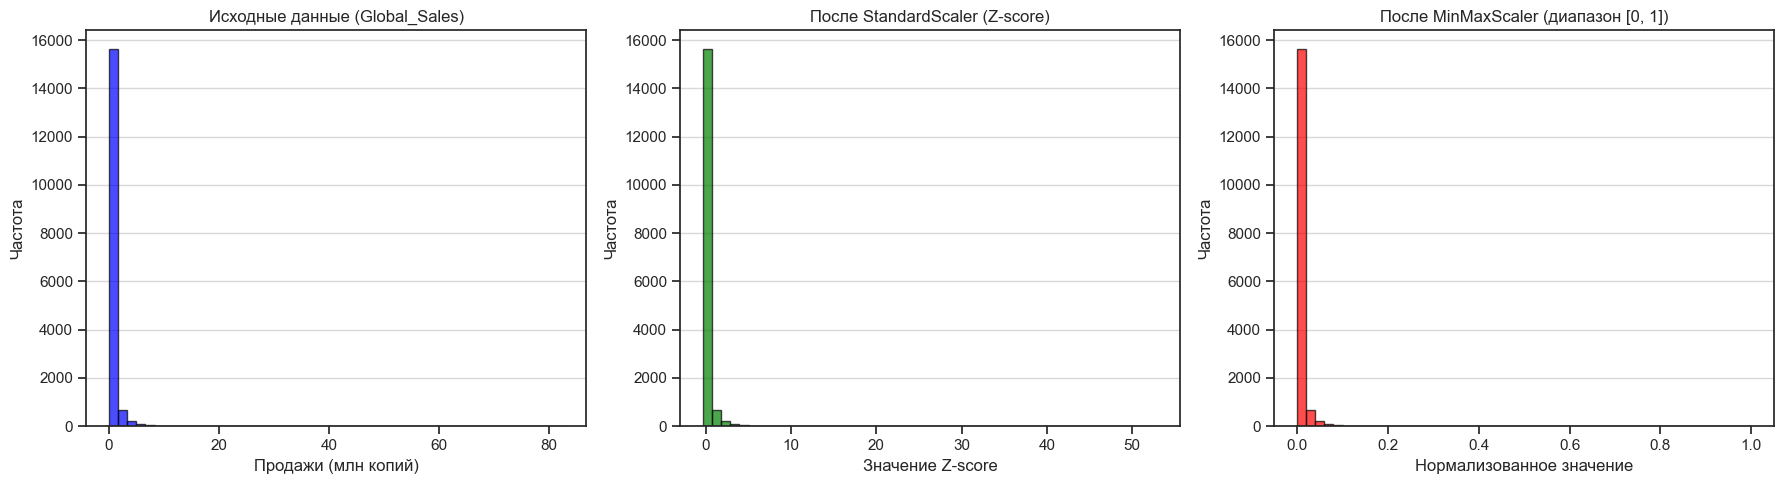

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Исходные данные (Global_Sales)
axes[0].hist(df_scaled['Global_Sales'], bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Исходные данные (Global_Sales)')
axes[0].set_xlabel('Продажи (млн копий)')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', alpha=0.75)

# StandardScaler
axes[1].hist(df_scaled_std['Global_Sales_Std'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('После StandardScaler (Z-score)')
axes[1].set_xlabel('Значение Z-score')
axes[1].set_ylabel('Частота')
axes[1].grid(axis='y', alpha=0.75)

# MinMaxScaler
axes[2].hist(df_scaled_minmax['Global_Sales_MinMax'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[2].set_title('После MinMaxScaler (диапазон [0, 1])')
axes[2].set_xlabel('Нормализованное значение')
axes[2].set_ylabel('Частота')
axes[2].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### 4.4. Сравнительная статистика до и после масштабирования

Выведем описательную статистику для исходных и масштабированных данных. Обратите внимание на среднее (mean) и стандартное отклонение (std) для колонок после `StandardScaler` (близки к 0 и 1 соответственно), а также на минимальное и максимальное значения после `MinMaxScaler` (строго 0 и 1).

In [16]:
print("Сравнительная статистика до и после масштабирования-")
df_scale_comparison.describe().round(2)

Сравнительная статистика до и после масштабирования-


,Global_Sales,Critic_Score,User_Count,Global_Sales_Std,Critic_Score_Std,User_Count_Std,Global_Sales_MinMax,Critic_Score_MinMax,User_Count_MinMax
count,16719.00,16719.00,16719.00,16719.00,16719.00,16719.00,16719.00,16719.00,16719.00
mean,0.53,70.01,86.75,-0.00,0.00,0.00,0.01,0.67,0.01
std,1.55,9.78,384.38,1.00,1.00,1.00,0.02,0.12,0.04
min,0.01,13.00,4.00,-0.34,-5.83,-0.22,0.00,0.00,0.00
25%,0.06,71.00,24.00,-0.31,0.10,-0.16,0.00,0.68,0.00
50%,0.17,71.00,24.00,-0.23,0.10,-0.16,0.00,0.68,0.00
75%,0.47,71.00,24.00,-0.04,0.10,-0.16,0.01,0.68,0.00
max,82.53,98.00,10665.00,52.97,2.86,27.52,1.00,1.00,1.00


## Заключение

В ходе выполнения лабораторной работы были освоены и применены на практике ключевые методы предварительной обработки данных с использованием библиотеки `scikit-learn`:

1.  **Обработка пропусков:**
    - Для числового признака `Year_of_Release` успешно применена импьютация медианой с помощью `SimpleImputer(strategy='median')`.
    - Для категориального признака `Rating` успешно применена импьютация константой `'Unknown'` с помощью `SimpleImputer(strategy='constant')`.

2.  **Кодирование категориальных признаков:**
    - Продемонстрирован `LabelEncoder` на примере колонки `Genre`.
    - Выполнено One-Hot кодирование колонки `Platform` с помощью `pd.get_dummies()`.
    - Вручную закодирован порядковый признак `Rating` с использованием словаря `map`.

3.  **Масштабирование данных:**
    - К числовым признакам `Global_Sales`, `Critic_Score` и `User_Count` применены `StandardScaler` (Z-оценка) и `MinMaxScaler` (масштабирование в диапазон [0, 1]).
    - Визуализация и сравнительная статистика подтвердили корректность преобразований.

Все поставленные задачи выполнены. Полученный в результате набор данных готов к дальнейшему использованию для построения моделей машинного обучения.